## Setup & Installation


In [ ]:
!pip install -q einops torchinfo tabulate

## Defining data paths

In [ ]:
import sys, os

# Detect Colab
IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # ---- Dataset / Output paths (edit if your Drive layout differs) ----
    DATASET_ROOT    = '/content/drive/MyDrive/CSE465/RRSIS-D'
    OUTPUT_DIR      = '/content/drive/MyDrive/CSE465/checkpoints'

    # ---- Locate the RMSIN repo on Drive (auto-search common locations) ----
    # Add your own path first if you know where it is; auto-search is a fallback.
    CANDIDATE_REPO_PATHS = [
        '/content/drive/MyDrive/CSE465/rmsin_src',
        '/content/drive/MyDrive/RRSIS-D_CSE465/Notebooks/rmsin_src',
        '/content/drive/MyDrive/rmsin_src',
        '/content/rmsin_src',  # in case user manually uploaded it to /content
    ]

    def _looks_like_rmsin_repo(path):
        """A valid repo must contain both lib/ and arc/ folders."""
        return (os.path.isdir(path)
                and os.path.isdir(os.path.join(path, 'lib'))
                and os.path.isdir(os.path.join(path, 'arc')))

    RMSIN_REPO_PATH = None
    for p in CANDIDATE_REPO_PATHS:
        if _looks_like_rmsin_repo(p):
            RMSIN_REPO_PATH = p
            break

    if RMSIN_REPO_PATH is None:
        # Search one level under Drive root as a last resort
        drive_root = '/content/drive/MyDrive'
        if os.path.exists(drive_root):
            for d, subdirs, _ in os.walk(drive_root):
                # skip deep traversal — only look 3 levels deep
                depth = d.replace(drive_root, '').count(os.sep)
                if depth > 3:
                    subdirs.clear()
                    continue
                if _looks_like_rmsin_repo(d):
                    RMSIN_REPO_PATH = d
                    break

    if RMSIN_REPO_PATH is None:
        raise FileNotFoundError(
            "Could not find the RMSIN repo (folder containing both 'lib/' and "
            "'arc/' subfolders) on your Google Drive.\n"
            "Checked: " + ', '.join(CANDIDATE_REPO_PATHS) + "\n"
            "Please upload the rmsin_src folder to Drive, then either:\n"
            "  (a) place it at one of the candidate paths above, or\n"
            "  (b) add the actual path to CANDIDATE_REPO_PATHS at the top of this cell."
        )

else:
    # Local fallback
    RMSIN_REPO_PATH = './RMSIN/rmsin_src'
    DATASET_ROOT    = './RRSIS-D'
    OUTPUT_DIR      = './checkpoints'

# ---- Ensure output dir exists ----
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Add repo to path (remove any stale entries first) ----
# Clean up any old /content/rmsin_src entries from previous sessions
sys.path[:] = [p for p in sys.path if p != '/content/rmsin_src' or p == RMSIN_REPO_PATH]
if RMSIN_REPO_PATH not in sys.path:
    sys.path.insert(0, RMSIN_REPO_PATH)

# ---- Dataset subfolders ----
IMAGE_DIR  = os.path.join(DATASET_ROOT, 'JPEGImages')
LABEL_DIR  = os.path.join(DATASET_ROOT, 'ann_split')

# ---- Debug prints ----
print("\nSetup Complete:")
print("Repo Path :", RMSIN_REPO_PATH)
print("Dataset   :", DATASET_ROOT)
print("Output    :", OUTPUT_DIR)

print("\nVerification:")
print("Repo exists?      ", os.path.isdir(RMSIN_REPO_PATH))
print("Repo/lib exists?  ", os.path.isdir(os.path.join(RMSIN_REPO_PATH, 'lib')))
print("Repo/arc exists?  ", os.path.isdir(os.path.join(RMSIN_REPO_PATH, 'arc')))
print("Image dir exists? ", os.path.exists(IMAGE_DIR))
print("Label dir exists? ", os.path.exists(LABEL_DIR))

if os.path.exists(DATASET_ROOT):
    print("\nDataset contents:")
    for item in sorted(os.listdir(DATASET_ROOT)):
        full = os.path.join(DATASET_ROOT, item)
        if os.path.isdir(full):
            print(f'  DIR  {item}: {len(os.listdir(full))} items')
        else:
            print(f'  FILE {item}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Setup Complete:
Repo Path : /content/drive/MyDrive/CSE465/rmsin_src
Dataset   : /content/drive/MyDrive/CSE465/RRSIS-D
Output    : /content/drive/MyDrive/CSE465/checkpoints

Verification:
Repo exists?       True
Repo/lib exists?   True
Repo/arc exists?   True
Image dir exists?  True
Label dir exists?  True

Dataset contents:
  DIR  JPEGImages: 17404 items
  DIR  ann_split: 17402 items
  FILE instances.json
  FILE refs(unc).p


## Import necessary libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as checkpoint_util
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict, OrderedDict
from typing import Optional
from torch import Tensor

import matplotlib.pyplot as plt
from tabulate import tabulate
from torchinfo import summary

import numpy as np
import random
import json
import pickle
import time
import datetime
import gc
import math
import warnings
from pathlib import Path

import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pycocotools import mask as maskUtils
import subprocess, shutil, json
%matplotlib inline


from transformers import FocalNetModel, FocalNetConfig

from transformers import BertModel, BertTokenizer
import timm
from timm.layers import DropPath, to_2tuple, trunc_normal_
from tqdm.notebook import tqdm

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

Device: cuda
GPU: NVIDIA L4
VRAM: 22.0 GB


## Reproductibility

In [ ]:
def seed_everything(seed=2401):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True       # ← fixed input 480x480, safe to enable
    torch.backends.cudnn.deterministic = False   # ← trade exact reproducibility for speed

seed_everything(2401)

In [ ]:
# Verify RMSIN repo imports — raises on failure so downstream cells don't silently
# run with missing names (which was the root cause of earlier NameError chain).

try:
    from arc import AdaptiveRotatedConv2d, RountingFunction
    print('[OK] arc (AdaptiveRotatedConv2d, RountingFunction)')
except ImportError as e:
    raise ImportError(
        f"Failed to import from 'arc': {e}\n"
        f"Check that RMSIN_REPO_PATH ({RMSIN_REPO_PATH}) contains an 'arc' folder "
        f"with a valid __init__.py exporting AdaptiveRotatedConv2d and RountingFunction."
    ) from e

try:
    from lib.cross_scale_interaction import CIM
    print('[OK] CIM (Cross-scale Interaction Module)')
except ImportError as e:
    raise ImportError(
        f"Failed to import CIM from lib.cross_scale_interaction: {e}\n"
        f"Check that {RMSIN_REPO_PATH}/lib/cross_scale_interaction.py exists."
    ) from e

try:
    from lib.various_receptive import VariousReceptive
    print('[OK] VariousReceptive')
except ImportError as e:
    raise ImportError(
        f"Failed to import VariousReceptive from lib.various_receptive: {e}\n"
        f"Check that {RMSIN_REPO_PATH}/lib/various_receptive.py exists."
    ) from e

print('\nAll repo imports successful!')

[OK] arc (AdaptiveRotatedConv2d, RountingFunction)
[OK] CIM (Cross-scale Interaction Module)
[OK] VariousReceptive

All repo imports successful!


## Configuration


In [ ]:
class Config:
    # Paths
    dataset_root = DATASET_ROOT
    output_dir   = OUTPUT_DIR
    resume       = ''

    # Dataset
    dataset  = 'rrsisd'
    splitBy  = 'unc'
    img_size = 480

    # Model
    swin_type   = 'base'
    window12    = True
    mha         = ''
    fusion_drop = 0.0
    bert_type   = 'bert-base-uncased'

    # Backbone selection
    backbone          = 'focalnet'
    focalnet_model    = 'microsoft/focalnet-base'

    # Mixed precision
    use_bf16 = True
    empty_cache_every = 20

    # Training
    epochs       = 40
    batch_size   = 16
    lr           = 3e-5
    weight_decay = 1e-2
    amsgrad      = False
    loss_weight  = 0.1
    max_tokens   = 20

    # DataLoader
    num_workers = 4
    pin_memory  = True

    # Logging
    print_freq = 10
    model_id   = 'RMSIN_RRSISD'

    # Derived (used when backbone='swin')
    @property
    def embed_dim(self):
        return {'tiny': 96, 'small': 96, 'base': 128, 'large': 192}[self.swin_type]
    @property
    def depths(self):
        return {'tiny': [2,2,6,2], 'small': [2,2,18,2],
                'base': [2,2,18,2], 'large': [2,2,18,2]}[self.swin_type]
    @property
    def num_heads_swin(self):
        return {'tiny': [3,6,12,24], 'small': [3,6,12,24],
                'base': [4,8,16,32], 'large': [6,12,24,48]}[self.swin_type]
    @property
    def window_size(self):
        return 12 if self.window12 else 7
    @property
    def mha_list(self):
        return [int(x) for x in self.mha.split('-')] if self.mha else [1,1,1,1]

cfg = Config()
print(f'Backbone: {cfg.backbone}')
if cfg.backbone == 'focalnet':
    print(f'FocalNet model: {cfg.focalnet_model}')
elif cfg.backbone == 'convnextv2':
    print(f'ConvNeXt-V2 model: {cfg.convnextv2_model}')
else:
    print(f'Swin: {cfg.swin_type} | embed_dim={cfg.embed_dim} | window={cfg.window_size}')
print(f'Training: epochs={cfg.epochs} | bs={cfg.batch_size} | lr={cfg.lr}')
print(f'max_tokens={cfg.max_tokens}')
print(f'output_dir: {cfg.output_dir}')

Backbone: focalnet
FocalNet model: microsoft/focalnet-base
Training: epochs=40 | bs=16 | lr=3e-05
max_tokens=20
output_dir: /content/drive/MyDrive/CSE465/checkpoints


## Data Exploration & Visualization


In [ ]:
instances_path = os.path.join(cfg.dataset_root, 'instances.json')
with open(instances_path, 'r') as f:
    instances = json.load(f)

print(f'Images:      {len(instances["images"])}')
print(f'Annotations: {len(instances["annotations"])}')
print(f'Categories:  {len(instances["categories"])}')

# Load referring expressions
refs_path = os.path.join(cfg.dataset_root, f'refs({cfg.splitBy}).p')
with open(refs_path, 'rb') as f:
    all_refs = pickle.load(f)

print(f'Referring expressions: {len(all_refs)}')

split_counts = defaultdict(int)
for ref in all_refs:
    split_counts[ref['split']] += 1
print('Splits:', dict(sorted(split_counts.items())))


Images:      17402
Annotations: 17402
Categories:  20
Referring expressions: 17402
Splits: {'test': 3481, 'train': 12181, 'val': 1740}


In [ ]:
# Mask decoding utility

img_dict = {img['id']: img for img in instances['images']}
ann_dict = {ann['id']: ann for ann in instances['annotations']}

def decode_mask(ann, img_info):
    """Decode COCO-format segmentation into binary mask."""
    seg = ann['segmentation']
    h, w = img_info['height'], img_info['width']

    def _safe_decode(rle, h, w):
        """Decode RLE and force to (h, w) if annotation size mismatches."""
        m = maskUtils.decode(rle)
        if m.shape[:2] != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        return m

    if isinstance(seg, dict):
        if isinstance(seg['counts'], list):
            rle = maskUtils.frPyObjects(seg, h, w)
        else:
            rle = seg
        m = _safe_decode(rle, h, w)

    elif isinstance(seg, list):
        if len(seg) > 0 and isinstance(seg[0], dict):
            # List of RLE dicts — decode each and accumulate
            m = np.zeros((h, w), dtype=np.uint8)
            for s in seg:
                m += _safe_decode(s, h, w)          # ← was the crash point
            m = (m > 0).astype(np.uint8)

        elif len(seg) > 0 and isinstance(seg[0], str):
            rle = {'counts': seg[0], 'size': [h, w]}
            m = _safe_decode(rle, h, w)

        else:
            # Polygon format
            rle = maskUtils.frPyObjects(seg, h, w)
            m = maskUtils.decode(rle)
            if m.ndim == 3:
                m = m.sum(axis=2)
            m = (m > 0).astype(np.uint8)
    else:
        m = np.zeros((h, w), dtype=np.uint8)

    if m.ndim == 3:
        m = m.sum(axis=2)
    return (m > 0).astype(np.uint8)

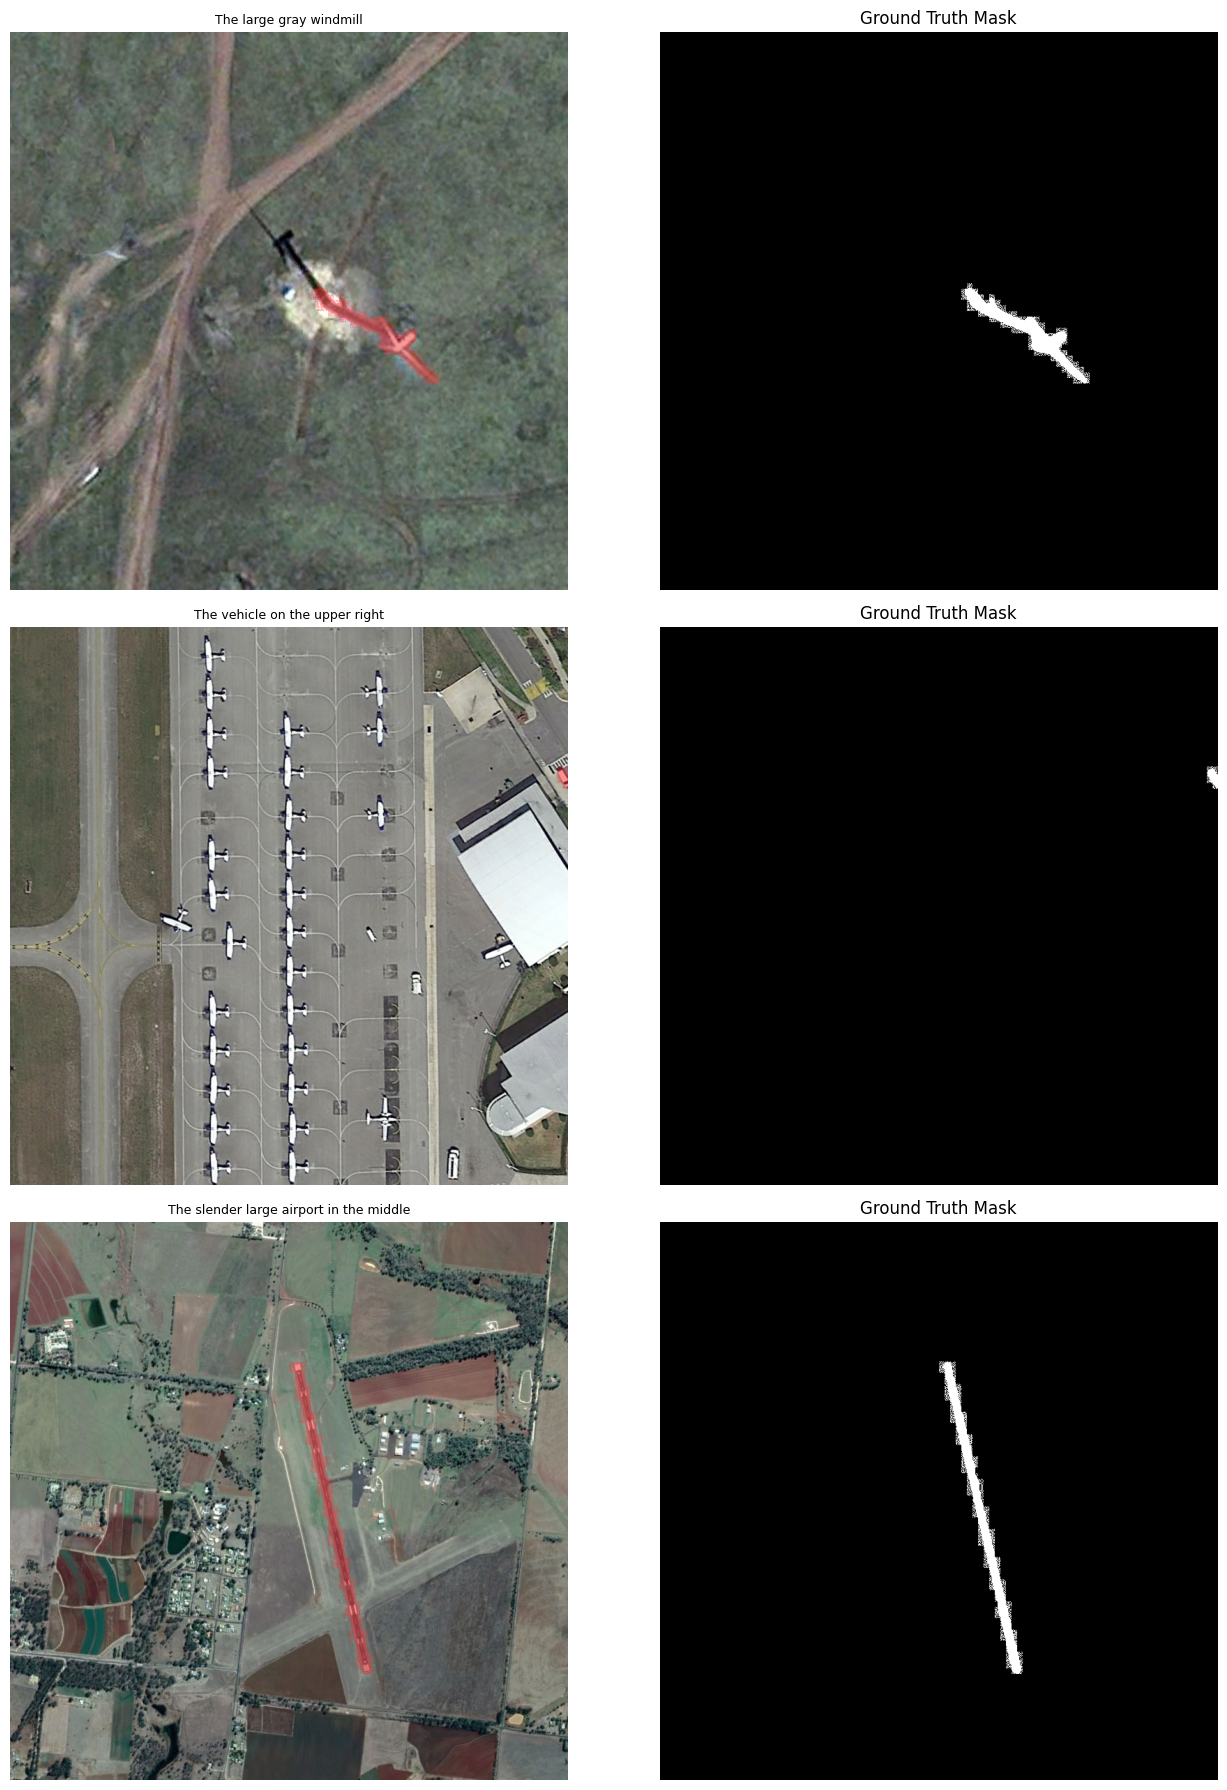

In [ ]:
# Visualize samples

img_dir = os.path.join(cfg.dataset_root, 'JPEGImages')

sample_refs = random.sample(all_refs, min(6, len(all_refs)))
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for i, ref in enumerate(sample_refs[:3]):
    img_info = img_dict[ref['image_id']]
    ann = ann_dict[ref['ann_id']]
    img = cv2.imread(os.path.join(img_dir, img_info['file_name']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask_arr = decode_mask(ann, img_info)

    # Image + overlay
    overlay = img.copy()
    overlay[mask_arr > 0] = (overlay[mask_arr > 0] * 0.5 +
                             np.array([255, 50, 50]) * 0.5).astype(np.uint8)
    sents = [s['sent'] for s in ref['sentences']]
    axes[i, 0].imshow(overlay)
    axes[i, 0].set_title('\n'.join(sents[:2]), fontsize=9, wrap=True)
    axes[i, 0].axis('off')

    # Mask
    axes[i, 1].imshow(mask_arr, cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


## Dataset & Transforms


In [ ]:
# Image Transforms (joint image + mask)

class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class Resize:
    def __init__(self, h, w):
        self.h, self.w = h, w
    def __call__(self, image, target):
        image = cv2.resize(image, (self.w, self.h), interpolation=cv2.INTER_LINEAR)
        target = cv2.resize(target, (self.w, self.h), interpolation=cv2.INTER_NEAREST)
        return image, target

class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, image, target):
        if random.random() < self.p:
            image = np.fliplr(image).copy()
            target = np.fliplr(target).copy()
        return image, target

class ToTensorPair:
    def __call__(self, image, target):
        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        target = torch.from_numpy(target).long()
        return image, target

class NormalizePair:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3,1,1)
        self.std  = torch.tensor(std).view(3,1,1)
    def __call__(self, image, target):
        return (image - self.mean) / self.std, target

def get_transform(split='train', img_size=480):
    t = [Resize(img_size, img_size)]
    # if split == 'train':
    #     t.append(RandomHorizontalFlip(0.5))
    t += [ToTensorPair(), NormalizePair([0.485,0.456,0.406], [0.229,0.224,0.225])]
    return Compose(t)

print('Transforms defined.')

Transforms defined.


In [ ]:
# RRSISDDataset — with HuggingFace BERT tokenizer

class RRSISDDataset(Dataset):

    def __init__(self, cfg, split='train', transform=None):
        self.cfg = cfg
        self.split = split
        self.transform = transform
        self.max_tokens = cfg.max_tokens
        self.img_dir = os.path.join(cfg.dataset_root, 'JPEGImages')

        tokenizer = BertTokenizer.from_pretrained(cfg.bert_type)

        # Load metadata
        with open(os.path.join(cfg.dataset_root, 'instances.json')) as f:
            inst = json.load(f)
        self.img_dict = {img['id']: img for img in inst['images']}
        self.ann_dict = {ann['id']: ann for ann in inst['annotations']}

        with open(os.path.join(cfg.dataset_root, f'refs({cfg.splitBy}).p'), 'rb') as f:
            refs = pickle.load(f)

        # Filter by split, flatten (ref, sentence) pairs
        self.samples = []
        for ref in refs:
            if ref['split'] == split:
                for sent in ref['sentences']:
                    self.samples.append({
                        'sent': sent['sent'],
                        'ann_id': ref['ann_id'],
                        'image_id': ref['image_id'],
                    })

        # ── PRE-TOKENIZE all sentences ONCE ────────────────────
        all_sents = [s['sent'] for s in self.samples]
        enc = tokenizer(
            all_sents,
            max_length=self.max_tokens,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        self.all_input_ids  = enc['input_ids']       # (N, max_tokens)
        self.all_attn_masks = enc['attention_mask']   # (N, max_tokens)
        del tokenizer  # free memory — no longer needed
        # ────────────────────────────────────────────────────────

        print(f'[{split}] {len(self.samples)} samples (pre-tokenized)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_info = self.img_dict[s['image_id']]
        img = cv2.imread(os.path.join(self.img_dir, img_info['file_name']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = decode_mask(self.ann_dict[s['ann_id']], img_info)

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask, self.all_input_ids[idx], self.all_attn_masks[idx]

In [ ]:
# Build DataLoaders


train_ds = RRSISDDataset(cfg, 'train', get_transform('train', cfg.img_size))
val_ds   = RRSISDDataset(cfg, 'val',   get_transform('val',   cfg.img_size))
test_ds  = RRSISDDataset(cfg, 'test',  get_transform('val',   cfg.img_size))

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=cfg.pin_memory, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)

print(f'Train: {len(train_loader)} batches (bs={cfg.batch_size})')
print(f'Val:   {len(val_loader)} batches (bs=4)')
print(f'Test:  {len(test_loader)} batches (bs=4)')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[train] 12181 samples (pre-tokenized)
[val] 1740 samples (pre-tokenized)
[test] 3481 samples (pre-tokenized)
Train: 761 batches (bs=16)
Val:   435 batches (bs=4)
Test:  871 batches (bs=4)


## Vision Backbone

In [ ]:
# PWAM — Pixel-Word Attention Module

class SpatialImageLanguageAttention(nn.Module):
    """
    Cross-modal attention: visual queries attend to language keys/values.
    This is the CORE fusion mechanism inside PWAM.

    Input shapes:
        x:      (B, H*W, v_in_channels)   — visual features
        l:      (B, l_in_channels, N_l)    — language features (channel-first!)
        l_mask: (B, N_l, 1)                — language attention mask

    Output: (B, H*W, value_channels)
    """
    def __init__(self, v_in_channels, l_in_channels, key_channels,
                 value_channels, out_channels=None, num_heads=1):
        super().__init__()
        self.v_in_channels = v_in_channels
        self.l_in_channels = l_in_channels
        self.out_channels = out_channels or value_channels
        self.key_channels = key_channels
        self.value_channels = value_channels
        self.num_heads = num_heads

        # Keys: from language (B, l_in, N_l) -> (B, key_ch, N_l)
        self.f_key = nn.Sequential(
            nn.Conv1d(l_in_channels, key_channels, 1, 1),
        )
        # Queries: from visual (B, v_in, H*W) -> (B, key_ch, H*W)
        self.f_query = nn.Sequential(
            nn.Conv1d(v_in_channels, key_channels, 1, 1),
            nn.InstanceNorm1d(key_channels),
        )
        # Values: from language
        self.f_value = nn.Sequential(
            nn.Conv1d(l_in_channels, value_channels, 1, 1),
        )
        # Output projection
        self.W = nn.Sequential(
            nn.Conv1d(value_channels, self.out_channels, 1, 1),
            nn.InstanceNorm1d(self.out_channels),
        )

    def forward(self, x, l, l_mask):
        # x: (B, H*W, v_in)  l: (B, l_in, N_l)  l_mask: (B, N_l, 1)
        B, HW = x.size(0), x.size(1)
        x_t = x.permute(0, 2, 1)              # (B, v_in, H*W)
        l_mask_t = l_mask.permute(0, 2, 1)     # (B, 1, N_l)

        query = self.f_query(x_t).permute(0, 2, 1)  # (B, H*W, key_ch)
        key   = self.f_key(l) * l_mask_t             # (B, key_ch, N_l)
        value = self.f_value(l) * l_mask_t           # (B, val_ch, N_l)
        n_l = value.size(-1)

        # Multi-head reshape
        query = query.reshape(B, HW, self.num_heads,
                              self.key_channels // self.num_heads).permute(0, 2, 1, 3)
        key   = key.reshape(B, self.num_heads,
                            self.key_channels // self.num_heads, n_l)
        value = value.reshape(B, self.num_heads,
                              self.value_channels // self.num_heads, n_l)

        # Scaled dot-product attention
        sim = torch.matmul(query, key) * (self.key_channels ** -0.5)
        sim = sim + (1e4 * l_mask_t.unsqueeze(1) - 1e4)  # mask padding
        sim = F.softmax(sim, dim=-1)                       # (B, heads, H*W, N_l)

        out = torch.matmul(sim, value.permute(0, 1, 3, 2))  # (B, heads, H*W, val//heads)
        out = out.permute(0, 2, 1, 3).contiguous().reshape(B, HW, self.value_channels)
        out = self.W(out.permute(0, 2, 1)).permute(0, 2, 1)  # (B, H*W, out_ch)
        return out


class PWAM(nn.Module):
    """
    Pixel-Word Attention Module — the cross-modal fusion module.

    ★★★ TO REPLACE WITH GNN: ★★★
    1. Keep the same __init__ signature (dim, v_in, l_in, key, value, heads, dropout)
    2. Keep the same forward signature: (x, l, l_mask) -> (B, H*W, dim)
    3. Replace self.image_lang_att with your GNN module
    4. Optionally keep or modify vis_project and project_mm
    """
    def __init__(self, dim, v_in_channels, l_in_channels,
                 key_channels, value_channels, num_heads=0, dropout=0.0):
        super().__init__()
        self.vis_project = nn.Sequential(
            nn.Conv1d(dim, dim, 1, 1),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.image_lang_att = SpatialImageLanguageAttention(
            v_in_channels, l_in_channels, key_channels, value_channels,
            out_channels=value_channels, num_heads=num_heads)

        self.project_mm = nn.Sequential(
            nn.Conv1d(value_channels, value_channels, 1, 1),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x, l, l_mask):
        # x: (B, H*W, dim)  l: (B, 768, N_l)  l_mask: (B, N_l, 1)
        vis  = self.vis_project(x.permute(0, 2, 1))  # (B, dim, H*W)
        lang = self.image_lang_att(x, l, l_mask)      # (B, H*W, dim)
        lang = lang.permute(0, 2, 1)                   # (B, dim, H*W)

        mm = torch.mul(vis, lang)                       # element-wise fusion
        mm = self.project_mm(mm)                        # (B, dim, H*W)
        return mm.permute(0, 2, 1)                      # (B, H*W, dim)


print('PWAM (Pixel-Word Attention Module) defined.')
print('  -> This is the fusion module to replace with GNN.')


PWAM (Pixel-Word Attention Module) defined.
  -> This is the fusion module to replace with GNN.


In [ ]:
# ============================================================
# MultiModalFocalNet  (★ ACTIVE BACKBONE ★)
# ============================================================
#  Drop-in replacement for MultiModalSwinTransformer / MultiModalConvNeXtV2.
#
#  Same forward(x, l, l_mask) → tuple(4 feature maps after CIM)
#  Same channel dims [128, 256, 512, 1024] for Base variant.
#
#  Per-stage flow (mirrors Swin / ConvNeXt-V2):
#    [FocalNet blocks at resolution R, channels C]
#      → PWAM fusion + VariousReceptive + gated residual (still at R×C)
#      → emit to decoder (normed)
#      → downsample (to R/2, 2C) — feeds next stage
#
#  Why this implementation is defensive:
#    - Forces the correct Base config (hub config.json may be stale/wrong)
#    - Iterates blocks + downsample manually (HF stage-level forward has
#      an API mismatch in some transformers versions)
#    - Gracefully handles weight-load mismatches
# ============================================================

import shutil as _shutil


def _purge_focalnet_cache():
    """Nuke any cached focalnet-base files that may be corrupt/mismatched."""
    cache_dirs = [
        os.path.expanduser('~/.cache/huggingface/hub/models--microsoft--focalnet-base'),
        os.path.expanduser('~/.cache/huggingface/transformers'),  # legacy
    ]
    for d in cache_dirs:
        if os.path.isdir(d):
            try:
                _shutil.rmtree(d)
                print(f'  purged cache: {d}')
            except Exception as e:
                print(f'  could not purge {d}: {e}')


def _build_focalnet_base_config():
    """Build the canonical FocalNet-Base config per the paper, sidestepping
    any bad config.json on the HF hub."""
    return FocalNetConfig(
        embed_dim=128,
        hidden_sizes=[128, 256, 512, 1024],
        depths=[2, 2, 18, 2],
        focal_levels=[3, 3, 3, 3],
        focal_windows=[3, 3, 3, 3],
        image_size=224,
        patch_size=4,
        mlp_ratio=4.0,
        drop_path_rate=0.3,
        use_conv_embed=False,
        use_layerscale=False,
        use_post_layernorm=False,
    )


def _load_focalnet_base(pretrained_model_name):
    """Load FocalNet-Base with guaranteed correct [128,256,512,1024] architecture.

    Strategy:
      1. Try from_pretrained with forced Base config + ignore_mismatched_sizes
      2. If weights dont match at all, fall back to random-init with a warning
    """
    override_cfg = _build_focalnet_base_config()

    try:
        focalnet = FocalNetModel.from_pretrained(
            pretrained_model_name,
            config=override_cfg,
            add_pooling_layer=False,
            ignore_mismatched_sizes=True,
        )
        print(f'  Loaded {pretrained_model_name} weights (mismatched sizes ignored)')
        return focalnet
    except Exception as e:
        print(f'  ⚠ from_pretrained failed: {e}')
        print(f'  Falling back to randomly-initialized FocalNet-Base.')
        return FocalNetModel(override_cfg, add_pooling_layer=False)


class MMFocalNetStage(nn.Module):
    """One stage of MultiModal FocalNet.

    Uses HF stage components (blocks + downsample) but orchestrates the
    forward pass manually to insert PWAM fusion between blocks and downsample.
    """
    def __init__(self, hf_stage, dim, next_dim=None,
                 num_heads_fusion=1, fusion_drop=0.0,
                 use_checkpoint=False):
        super().__init__()
        self.dim = dim
        self.next_dim = next_dim if next_dim is not None else dim
        self.use_checkpoint = use_checkpoint

        # Reference HF components (they remain trainable)
        self.blocks = hf_stage.layers       # ModuleList of FocalNetLayer
        # HF's last stage has downsample=None; earlier stages have FocalNetPatchEmbeddings.
        # We store it as a plain attribute (not submodule) when None to avoid nn.Module issues.
        _ds = hf_stage.downsample
        if _ds is None:
            self.downsample = None
        else:
            self.downsample = _ds  # registered as a submodule automatically

        # Cross-modal fusion — identical to MMBasicLayer / MMConvNeXtV2Stage
        self.fusion = PWAM(
            dim, dim, 768, dim, dim,
            num_heads=num_heads_fusion, dropout=fusion_drop,
        )
        self.res_gate = nn.Sequential(
            nn.Linear(dim, dim, bias=False), nn.ReLU(),
            nn.Linear(dim, dim, bias=False), nn.Tanh(),
        )
        self.visual_residual = VariousReceptive(dim)
        self.visual_gate = nn.Sequential(
            nn.Linear(dim, dim, bias=False), nn.ReLU(),
            nn.Linear(dim, dim, bias=False), nn.Tanh(),
        )

    def _run_blocks(self, x, H, W):
        """Run all focal-modulation blocks at the given resolution.
        Handles varying HF block return signatures defensively."""
        for blk in self.blocks:
            out = blk(x, (H, W))
            # Different HF versions return:
            #   (hidden_states,) | hidden_states | (hidden_states, (H,W))
            if isinstance(out, tuple):
                x = out[0]
            else:
                x = out
        return x

    def _apply_downsample(self, x_fused, H, W):
        """Apply HF's downsample (NCHW in → (tokens, (H',W')) out),
        or pass through if None/Identity (last stage)."""
        if self.downsample is None or isinstance(self.downsample, nn.Identity):
            return x_fused, H, W
        # HF FocalNetPatchEmbeddings: NCHW → (tokens_NLC, (H', W'))
        x_nchw = x_fused.transpose(1, 2).reshape(-1, self.dim, H, W).contiguous()
        ds_out = self.downsample(x_nchw)
        if isinstance(ds_out, tuple) and len(ds_out) >= 2:
            x_next, dims_next = ds_out[0], ds_out[1]
            if isinstance(dims_next, (tuple, list)) and len(dims_next) >= 2:
                H_next, W_next = dims_next[0], dims_next[1]
            else:
                H_next = (H + 1) // 2
                W_next = (W + 1) // 2
        else:
            x_next = ds_out[0] if isinstance(ds_out, tuple) else ds_out
            H_next = (H + 1) // 2
            W_next = (W + 1) // 2
        return x_next, H_next, W_next

    def forward(self, x, H, W, l, l_mask):
        """
        Args:
            x:      (B, H*W, C)   tokens at current stage resolution
            H, W:   int           current spatial dims
            l:      (B, 768, N_l) language features (channel-first)
            l_mask: (B, N_l, 1)   language mask
        Returns:
            x_residual:  (B, H*W, C)   PWAM output (for decoder)
            x_next:      (B, H'*W', C')  tokens for next stage
            H_next, W_next: int, int    next-stage spatial dims
        """
        # ── Focal-modulation blocks at current resolution ──
        if self.use_checkpoint and self.training:
            x = checkpoint_util.checkpoint(
                self._run_blocks, x, H, W, use_reentrant=False)
        else:
            x = self._run_blocks(x, H, W)

        # ── Cross-modal fusion at current resolution ──
        v_residual = self.visual_residual(x)
        x_residual = self.fusion(x, l, l_mask)

        x_fused = x + (self.res_gate(x_residual) * x_residual) + \
                      (self.visual_gate(v_residual) * v_residual)

        # ── Downsample for next stage ──
        x_next, H_next, W_next = self._apply_downsample(x_fused, H, W)
        return x_residual, x_next, H_next, W_next


class MultiModalFocalNet(nn.Module):
    """Full multi-modal FocalNet backbone.

    Architecture (mirrors MultiModalSwinTransformer):
        Image → Stem(4x↓) → [Stage0 → Stage1 → Stage2 → Stage3] → CIM
        Each stage: FocalNet blocks → PWAM fusion → gating → downsample

    Channel dims for Base: [128, 256, 512, 1024].
    """
    def __init__(self, pretrained_model_name='microsoft/focalnet-base',
                 out_indices=(0, 1, 2, 3),
                 use_checkpoint=False,
                 num_heads_fusion=[1, 1, 1, 1],
                 fusion_drop=0.0):
        super().__init__()
        self.out_indices = out_indices

        print(f'Loading FocalNet from: {pretrained_model_name}')

        # ── First attempt ──
        focalnet = _load_focalnet_base(pretrained_model_name)

        # Verify the loaded model has Base dimensions. If not, purge cache + retry.
        if list(focalnet.config.hidden_sizes) != [128, 256, 512, 1024]:
            print(f'  ⚠ Got hidden_sizes={focalnet.config.hidden_sizes}, expected '
                  f'[128,256,512,1024]. Purging cache and retrying...')
            del focalnet
            _purge_focalnet_cache()
            focalnet = _load_focalnet_base(pretrained_model_name)

        hf_config = focalnet.config
        self.hidden_sizes = list(hf_config.hidden_sizes)
        self.num_features = self.hidden_sizes

        # Hard assertion — if this fails, we genuinely cannot proceed.
        assert self.hidden_sizes == [128, 256, 512, 1024], (
            f"FocalNet-Base hidden_sizes mismatch: {self.hidden_sizes}. "
            f"This shouldnt happen after the retry. Please file a bug.")

        print(f'  embed_dim (stem)  = {hf_config.embed_dim}')
        print(f'  hidden_sizes      = {self.hidden_sizes}')
        print(f'  depths per stage  = {list(hf_config.depths)}')

        # Stem: FocalNetEmbeddings → returns (tokens_NLC, (H/4, W/4))
        self.stem = focalnet.embeddings

        # Wrap each HF stage.
        self.mm_stages = nn.ModuleList()
        for i, hf_stage in enumerate(focalnet.encoder.stages):
            next_dim = self.hidden_sizes[i+1] if i < len(self.hidden_sizes)-1 else self.hidden_sizes[i]
            self.mm_stages.append(MMFocalNetStage(
                hf_stage=hf_stage,
                dim=self.hidden_sizes[i],
                next_dim=next_dim,
                num_heads_fusion=num_heads_fusion[i],
                fusion_drop=fusion_drop,
                use_checkpoint=use_checkpoint and (i >= 1),
            ))

        # Output norms (one per out_index) applied on PWAM residuals before decoder
        for i in out_indices:
            self.add_module(f'norm{i}', nn.LayerNorm(self.hidden_sizes[i]))

        # Cross-scale Interaction Module
        self.cim = CIM(dim=sum(self.hidden_sizes))

        del focalnet  # inner modules are still alive via mm_stages / stem

    def forward(self, x, l, l_mask):
        """Same signature as MultiModalSwinTransformer.forward()."""
        # Stem — HF FocalNetEmbeddings returns (tokens_NLC, (H/4, W/4))
        stem_out = self.stem(x)
        if isinstance(stem_out, tuple):
            x = stem_out[0]
            dims = stem_out[1]
            if isinstance(dims, (tuple, list)) and len(dims) >= 2:
                H, W = dims[0], dims[1]
            else:
                N = x.shape[1]
                H = W = int(N ** 0.5)
        else:
            x = stem_out
            N = x.shape[1]
            H = W = int(N ** 0.5)

        outs = []
        for i, mm_stage in enumerate(self.mm_stages):
            x_residual, x_next, H_next, W_next = mm_stage(x, H, W, l, l_mask)

            if i in self.out_indices:
                norm_layer = getattr(self, f'norm{i}')
                x_out = norm_layer(x_residual)
                out   = x_out.view(-1, H, W, self.hidden_sizes[i]) \
                             .permute(0, 3, 1, 2).contiguous()
                outs.append(out)

            x, H, W = x_next, H_next, W_next

        outs = self.cim(outs)
        return tuple(outs)

    def train(self, mode=True):
        super().train(mode)


print('MultiModalFocalNet defined.')
print('  -> Same forward(x, l, l_mask) as MultiModalSwinTransformer')
print('  -> Channels [128, 256, 512, 1024] — decoder/CIM/PWAM unchanged')

MultiModalFocalNet defined.
  -> Same forward(x, l, l_mask) as MultiModalSwinTransformer
  -> Channels [128, 256, 512, 1024] — decoder/CIM/PWAM unchanged


## Decoder- SimpleDecoding


In [ ]:
# SimpleDecoding with optional Adaptive Rotated Conv

def make_arc_or_conv(in_ch, out_ch, ks=3, pad=1, bias=False):
    """Use ARC if available, else standard Conv2d."""
    try:
        rf = RountingFunction(in_channels=in_ch, kernel_number=1)
        return AdaptiveRotatedConv2d(
            in_channels=in_ch, out_channels=out_ch,
            kernel_size=ks, padding=pad,
            rounting_func=rf, bias=bias, kernel_number=1)
    except Exception:
        return nn.Conv2d(in_ch, out_ch, ks, padding=pad, bias=bias)


class SimpleDecoding(nn.Module):
    """FPN-style top-down decoder with ARC."""
    def __init__(self, c4_dims, factor=2):
        super().__init__()
        h = c4_dims // factor
        c3 = c4_dims // (factor**1)
        c2 = c4_dims // (factor**2)
        c1 = c4_dims // (factor**3)

        # Stage 4+3
        self.conv1_4 = nn.Conv2d(c4_dims + c3, h, 3, padding=1, bias=False)
        self.conv2_4 = make_arc_or_conv(h, h)
        self.bn1_4, self.bn2_4 = nn.BatchNorm2d(h), nn.BatchNorm2d(h)
        self.relu1_4, self.relu2_4 = nn.ReLU(), nn.ReLU()
        # Stage +2
        self.conv1_3 = nn.Conv2d(h + c2, h, 3, padding=1, bias=False)
        self.conv2_3 = make_arc_or_conv(h, h)
        self.bn1_3, self.bn2_3 = nn.BatchNorm2d(h), nn.BatchNorm2d(h)
        self.relu1_3, self.relu2_3 = nn.ReLU(), nn.ReLU()
        # Stage +1
        self.conv1_2 = nn.Conv2d(h + c1, h, 3, padding=1, bias=False)
        self.conv2_2 = make_arc_or_conv(h, h)
        self.bn1_2, self.bn2_2 = nn.BatchNorm2d(h), nn.BatchNorm2d(h)
        self.relu1_2, self.relu2_2 = nn.ReLU(), nn.ReLU()
        # Head
        self.head = nn.Conv2d(h, 2, 1)

    def forward(self, x_c4, x_c3, x_c2, x_c1):
        if x_c4.size(-2) < x_c3.size(-2) or x_c4.size(-1) < x_c3.size(-1):
            x_c4 = F.interpolate(x_c4, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.relu1_4(self.bn1_4(self.conv1_4(torch.cat([x_c4, x_c3], 1))))
        x = self.relu2_4(self.bn2_4(self.conv2_4(x)))

        if x.size(-2) < x_c2.size(-2) or x.size(-1) < x_c2.size(-1):
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.relu1_3(self.bn1_3(self.conv1_3(torch.cat([x, x_c2], 1))))
        x = self.relu2_3(self.bn2_3(self.conv2_3(x)))

        if x.size(-2) < x_c1.size(-2) or x.size(-1) < x_c1.size(-1):
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.relu1_2(self.bn1_2(self.conv1_2(torch.cat([x, x_c1], 1))))
        x = self.relu2_2(self.bn2_2(self.conv2_2(x)))

        return self.head(x)

print('SimpleDecoding defined.')


SimpleDecoding defined.


## Model Assembly (RMSINModel - full model with HF BERT)

In [ ]:
class RMSINModel(nn.Module):
    def __init__(self, backbone, classifier, cfg):
        super().__init__()
        self.backbone = backbone
        self.classifier = classifier
        self.text_encoder = BertModel.from_pretrained(cfg.bert_type)
        self.text_encoder.pooler = None

    def forward(self, image, sentences, attentions):
        """
        image:      (B, 3, H, W)
        sentences:  (B, N_l) token IDs
        attentions: (B, N_l) attention mask
        """
        # Text encoding
        bert_out = self.text_encoder(input_ids=sentences, attention_mask=attentions)
        l_feats = bert_out.last_hidden_state.permute(0, 2, 1)  # (B, 768, N_l)
        l_mask  = attentions.unsqueeze(-1).float()              # (B, N_l, 1)

        # Vision backbone with cross-modal fusion
        features = self.backbone(image, l_feats, l_mask)

        # Decode
        x_c1, x_c2, x_c3, x_c4 = features
        return self.classifier(x_c4, x_c3, x_c2, x_c1)

print('RMSINModel defined.')


RMSINModel defined.


## Build & load pretrained weights

In [ ]:
def build_model(cfg):
    backbone_type = getattr(cfg, 'backbone', 'focalnet')

    if backbone_type == 'focalnet':
        focalnet_name = getattr(cfg, 'focalnet_model', 'microsoft/focalnet-base')
        backbone = MultiModalFocalNet(
            pretrained_model_name=focalnet_name,
            out_indices=(0, 1, 2, 3),
            use_checkpoint=True,
            num_heads_fusion=cfg.mha_list,
            fusion_drop=cfg.fusion_drop,
        )
        decoder_dim = backbone.hidden_sizes[-1]            # 1024

    else:
        raise ValueError(
            f"Unknown backbone '{backbone_type}'. Supported (active): 'focalnet'. "
            "Swin and ConvNeXt-V2 branches are commented out — uncomment their "
            "corresponding sections (5a-5e) and this branch to use them.")

    classifier = SimpleDecoding(decoder_dim)
    model      = RMSINModel(backbone, classifier, cfg)

    # ── Freeze BERT layers 10 & 11 + embeddings ──
    for i in [10, 11]:
        for p in model.text_encoder.encoder.layer[i].parameters():
            p.requires_grad = False
    for p in model.text_encoder.embeddings.parameters():
        p.requires_grad = False

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    print(f'Backbone: {backbone_type}')
    print(f'Total: {total:,} | Trainable: {trainable:,} | Frozen: {frozen:,}')
    print(f'Gradient checkpointing: ENABLED')
    return model

model = build_model(cfg).to(DEVICE)
print(f'Model on: {next(model.parameters()).device}')

Loading FocalNet from: microsoft/focalnet-base


Loading weights:   0%|          | 0/402 [00:00<?, ?it/s]

FocalNetModel LOAD REPORT from: microsoft/focalnet-base
Key                                                                            | Status     |                                                                                           
-------------------------------------------------------------------------------+------------+-------------------------------------------------------------------------------------------
classifier.weight                                                              | UNEXPECTED |                                                                                           
classifier.bias                                                                | UNEXPECTED |                                                                                           
encoder.stages.{0, 1, 2, 3}.layers.{0...17}.modulation.focal_layers.2.0.weight | MISSING    |                                                                                           
encoder.stages.{0, 

  Loaded microsoft/focalnet-base weights (mismatched sizes ignored)
  embed_dim (stem)  = 128
  hidden_sizes      = [128, 256, 512, 1024]
  depths per stage  = [2, 2, 18, 2]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Backbone: focalnet
Total: 240,883,347 | Trainable: 202,870,419 | Frozen: 38,012,928
Gradient checkpointing: ENABLED
Model on: cuda:0


## View Model Architecture

In [ ]:
def print_model_architecture(model):

    # ── Top-level module breakdown ───────────────────────────
    print("\n" + "="*70)
    print("  LEVEL 1 — Top-Level Module Breakdown")
    print("="*70)
    rows = []
    for name, module in model.named_children():
        n_params    = sum(p.numel() for p in module.parameters())
        n_trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
        rows.append([name, module.__class__.__name__,
                     f"{n_params:,}", f"{n_trainable:,}",
                     f"{n_params * 4 / 1024**2:.2f} MB"])
    print(tabulate(rows,
                   headers=["Module Name", "Class", "Total Params",
                             "Trainable Params", "Approx Size (fp32)"],
                   tablefmt="rounded_outline"))

    # ── Grand total ──────────────────────────────────────────
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    size_fp32 = total * 4 / 1024**2
    size_fp16 = total * 2 / 1024**2

    print("\n" + "="*70)
    print("  GRAND TOTAL")
    print("="*70)
    print(tabulate([
        ["Total parameters",     f"{total:,}"],
        ["Trainable parameters", f"{trainable:,}"],
        ["Frozen parameters",    f"{frozen:,}"],
        ["Model size (fp32)",    f"{size_fp32:.2f} MB"],
        ["Model size (fp16)",    f"{size_fp16:.2f} MB"],
        ["Est. training VRAM*",  f"~{size_fp32 * 4:.0f} MB  (weights + grads + Adam)"],
    ], tablefmt="rounded_outline"))
    print("  * activations not included — depends on batch size & resolution\n")


print_model_architecture(model)


  LEVEL 1 — Top-Level Module Breakdown
╭───────────────┬────────────────────┬────────────────┬────────────────────┬──────────────────────╮
│ Module Name   │ Class              │ Total Params   │ Trainable Params   │ Approx Size (fp32)   │
├───────────────┼────────────────────┼────────────────┼────────────────────┼──────────────────────┤
│ backbone      │ MultiModalFocalNet │ 111,320,718    │ 111,320,718        │ 424.65 MB            │
│ classifier    │ SimpleDecoding     │ 20,670,981     │ 20,670,981         │ 78.85 MB             │
│ text_encoder  │ BertModel          │ 108,891,648    │ 70,878,720         │ 415.39 MB            │
╰───────────────┴────────────────────┴────────────────┴────────────────────┴──────────────────────╯

  GRAND TOTAL
╭──────────────────────┬────────────────────────────────────╮
│ Total parameters     │ 240,883,347                        │
│ Trainable parameters │ 202,870,419                        │
│ Frozen parameters    │ 38,012,928                        

## Loss Function (Combined CE + Dice Loss)


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        C = pred.shape[1]
        pred_soft = F.softmax(pred, dim=1)
        target_oh = torch.stack([target == c for c in range(C)], dim=1).float()
        inter = (pred_soft * target_oh).sum(dim=(2, 3))
        union = (pred_soft + target_oh).sum(dim=(2, 3))
        return (1 - (2*inter + self.smooth) / (union + self.smooth)).mean()

class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.1):
        super().__init__()
        self.dice_weight = dice_weight
        # ── CHANGED: register weight as buffer so it moves with .to() ──
        self.register_buffer('ce_weight', torch.FloatTensor([0.9, 1.1]))
        self.dice = DiceLoss()

    def forward(self, pred, target):
        if pred.shape[-2:] != target.shape[-2:]:
            pred = F.interpolate(pred, size=target.shape[-2:],
                                 mode='bilinear', align_corners=False)
        target_long = target.squeeze(1).long()
        ce_loss = F.cross_entropy(pred, target_long, weight=self.ce_weight)
        return ((1 - self.dice_weight) * ce_loss
                + self.dice_weight     * self.dice(pred, target_long))

criterion = CombinedLoss(dice_weight=cfg.loss_weight).to(DEVICE)
print(f'Loss: CE({1-cfg.loss_weight:.1f}) + Dice({cfg.loss_weight:.1f})')


Loss: CE(0.9) + Dice(0.1)


## Evaluation Metrices


In [ ]:
# IoU metric

def compute_iou(pred, target):
    # pred: [B, 2, H, W] logits — upsample first, then argmax
    if pred.shape[-2:] != target.shape[-2:]:
        pred = F.interpolate(pred, size=target.shape[-2:],
                             mode='bilinear', align_corners=False)
    pred_mask  = pred.argmax(dim=1)                    # [B, H, W]
    target_bin = target.squeeze(1).long()              # [B, H, W]
    I = (pred_mask * target_bin).sum().item()
    U = (pred_mask + target_bin).clamp(max=1).sum().item()
    if U == 0:
        return 1.0, 0, 0                               # empty mask edge case
    return I / U, I, U

In [ ]:
# Segmentation Metrics  (oIoU, mIoU, Pr@K)


class SegmentationMetrics:
    """
    Accumulates per-batch predictions and computes:
      - oIoU  : overall IoU (global intersection / global union)
      - mIoU  : mean of per-image IoU scores
      - Pr@K  : fraction of images with per-image IoU >= K  (K in {0.5, 0.7, 0.9})
    All inputs expected as binary tensors (0/1) on any device.
    """
    THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9]

    def __init__(self):
        self.reset()

    def reset(self):
        self._total_inter = 0.0
        self._total_union = 0.0
        self._per_image_ious = []

    def update(self, pred_mask: torch.Tensor, gt_mask: torch.Tensor):
        """
        pred_mask : (B, 1, H, W) or (B, H, W) — binary, float or bool
        gt_mask   : same shape
        """
        pred = (pred_mask > 0.5).float().view(pred_mask.shape[0], -1)
        gt   = (gt_mask   > 0.5).float().view(gt_mask.shape[0],   -1)

        inter = (pred * gt).sum(dim=1)           # (B,)
        union = (pred + gt).clamp(max=1).sum(dim=1)  # (B,)

        # oIoU accumulation
        self._total_inter += inter.sum().item()
        self._total_union += union.sum().item()

        # per-image IoU (avoid div-by-zero for empty gt)
        per_iou = torch.where(union > 0,
                              inter / union,
                              torch.ones_like(inter))  # empty mask → IoU=1
        self._per_image_ious.extend(per_iou.cpu().tolist())

    def compute(self) -> dict:
        oiou = self._total_inter / (self._total_union + 1e-8)
        ious  = np.array(self._per_image_ious)
        miou  = float(ious.mean())
        results = {"oIoU": oiou, "mIoU": miou}
        for k in self.THRESHOLDS:
            results[f"Pr@{k}"] = float((ious >= k).mean())
        return results


## Tracking & Logging

In [ ]:
# Time Trackers

class EpochTimer:
    """Tracks per-epoch training and validation wall-clock time."""

    def __init__(self):
        self._start = None
        self.records = []          # list of dicts

    def start(self):
        self._start = time.perf_counter()

    def stop(self, label="epoch"):
        elapsed = time.perf_counter() - self._start
        self.records.append({"label": label, "seconds": elapsed})
        return elapsed

    def summary(self):
        if not self.records:
            return
        print("\n── Epoch Timing Summary ──────────────────────────────")
        rows = []
        for r in self.records:
            rows.append([r["label"],
                         f"{r['seconds']:.1f}s",
                         str(datetime.timedelta(seconds=int(r['seconds'])))])
        total = sum(r["seconds"] for r in self.records)
        print(tabulate(rows, headers=["Phase", "Seconds", "H:M:S"], tablefmt="simple"))
        print(f"  Total elapsed : {datetime.timedelta(seconds=int(total))}\n")


class InferenceTimer:
    """
    Measures per-sample inference latency with GPU warm-up and CUDA sync.
    Usage:
        timer = InferenceTimer(model, device)
        stats = timer.measure(val_loader, n_samples=100)
        timer.report(stats)
    """

    def __init__(self, model, device):
        self.model  = model
        self.device = device

    @torch.no_grad()
    def measure(self, loader, n_samples=100):
        self.model.eval()
        latencies = []

        # GPU warm-up — runs 5 batches without recording
        for i, (img, msk, ids, attn) in enumerate(loader):
            if i >= 5:
                break
            img, ids, attn = img.to(self.device), ids.to(self.device), attn.to(self.device)
            _ = self.model(img, ids, attn)

        if self.device.type == "cuda":
            torch.cuda.synchronize()

        # Timed loop
        for i, (img, msk, ids, attn) in enumerate(loader):
            if i >= n_samples:
                break
            img  = img.to(self.device)
            ids  = ids.to(self.device)
            attn = attn.to(self.device)

            if self.device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()

            _ = self.model(img, ids, attn)

            if self.device.type == "cuda":
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)  # ms

        return {
            "n_samples"  : len(latencies),
            "mean_ms"    : np.mean(latencies),
            "std_ms"     : np.std(latencies),
            "min_ms"     : np.min(latencies),
            "max_ms"     : np.max(latencies),
            "median_ms"  : np.median(latencies),
            "fps"        : 1000.0 / np.mean(latencies),
        }

    def report(self, stats):
        print("\n── Inference Latency (batch_size=1) ──────────────────")
        rows = [
            ["Samples measured",  stats["n_samples"]],
            ["Mean latency",      f"{stats['mean_ms']:.2f} ms"],
            ["Std deviation",     f"{stats['std_ms']:.2f} ms"],
            ["Median latency",    f"{stats['median_ms']:.2f} ms"],
            ["Min / Max",         f"{stats['min_ms']:.2f} ms / {stats['max_ms']:.2f} ms"],
            ["Throughput",        f"{stats['fps']:.1f} FPS"],
        ]
        print(tabulate(rows, tablefmt="rounded_outline"))
        print()


In [ ]:
# Epoch Logger

class EpochLogger:
    """
    Stores per-epoch train/val loss and metrics, supports:
      - dict-style access
      - JSON export for reporting
      - plotting loss + oIoU/mIoU curves in one call
    """

    def __init__(self, save_dir: str = "."):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.history = defaultdict(list)   # key → list of values per epoch

    def log(self, epoch: int, **kwargs):
        """Call once per epoch with any key=value pairs."""
        self.history["epoch"].append(epoch)
        for k, v in kwargs.items():
            self.history[k].append(float(v))

        # Print a clean one-liner
        parts = [f"Epoch {epoch:>3}"]
        for k, v in kwargs.items():
            parts.append(f"{k}: {v:.4f}")
        print("  │  ".join(parts))

    def save_json(self, filename="training_log.json"):
        path = self.save_dir / filename
        with open(path, "w") as f:
            json.dump(dict(self.history), f, indent=2)
        print(f"[Logger] History saved → {path}")

    def plot_curves(self, filename="training_curves.png"):
        epochs = self.history["epoch"]
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Training Curves", fontsize=14, fontweight="bold")

        # ── Plot 1: Loss ──────────────────────────────────────
        ax = axes[0]
        if "train_loss" in self.history:
            ax.plot(epochs, self.history["train_loss"], label="Train Loss",
                    color="#2196F3", linewidth=2, marker="o", markersize=3)
        if "val_loss" in self.history:
            ax.plot(epochs, self.history["val_loss"],   label="Val Loss",
                    color="#F44336", linewidth=2, marker="o", markersize=3)
        ax.set_title("Loss (CE + Dice)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # ── Plot 2: IoU curves (equiv. of accuracy) ───────────
        ax = axes[1]
        for key, color, label in [
            ("train_oIoU", "#2196F3", "Train oIoU"),
            ("val_oIoU",   "#F44336", "Val oIoU"),
            ("train_mIoU", "#4CAF50", "Train mIoU"),
            ("val_mIoU",   "#FF9800", "Val mIoU"),
        ]:
            if key in self.history:
                ax.plot(epochs, self.history[key], label=label,
                        linewidth=2, marker="o", markersize=3)
        ax.set_title("IoU Metrics (segmentation accuracy)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("IoU")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)

        # ── Plot 3: Precision @ thresholds ────────────────────
        ax = axes[2]
        threshold_styles = {
            "val_Pr@0.5": ("#E91E63", "Pr@0.5"),
            "val_Pr@0.7": ("#9C27B0", "Pr@0.7"),
            "val_Pr@0.9": ("#607D8B", "Pr@0.9"),
        }
        for key, (color, label) in threshold_styles.items():
            if key in self.history:
                ax.plot(epochs, self.history[key], label=label,
                        color=color, linewidth=2, marker="o", markersize=3)
        ax.set_title("Val Precision @ IoU Thresholds")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Fraction of images")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        path = self.save_dir / filename
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[Logger] Curves saved → {path}")


## Model Checkpoints

In [ ]:
def save_checkpoint(model, optimizer, scheduler, epoch, best_oiou, cfg, is_best=False):
    ckpt = {
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'epoch'    : epoch,
        'best_oiou': best_oiou,
    }

    last_path = os.path.join(cfg.output_dir, f'{cfg.model_id}_last.pth')
    best_path = os.path.join(cfg.output_dir, f'{cfg.model_id}_best.pth')

    # Save last checkpoint
    torch.save(ckpt, last_path)
    print(f'  ✔ Last checkpoint saved: {last_path}')

    # Save best checkpoint
    if is_best:
        torch.save(ckpt, best_path)
        print(f'  ⭐ Best model saved! oIoU={best_oiou:.2f}%')


def load_checkpoint(model, optimizer, scheduler, cfg):
    path = cfg.resume or os.path.join(cfg.output_dir, f'{cfg.model_id}_last.pth')

    if os.path.exists(path):
        print(f'Resuming from {path}')

        ckpt = torch.load(path, map_location=DEVICE)

        model.load_state_dict(ckpt['model'], strict=False)
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])

        # Restore learning rates (important for your setup)
        lr_per_group = [cfg.lr, cfg.lr, cfg.lr, cfg.lr * 0.1]
        for pg, lr in zip(optimizer.param_groups, lr_per_group):
            pg['lr'] = lr

        print(f'  LRs restored: backbone/decoder={cfg.lr} | BERT={cfg.lr * 0.1}')

        return ckpt['epoch'] + 1, ckpt.get('best_oiou', -1)

    print('No checkpoint found. Starting fresh.')
    return 0, -1.0

## Training Infrastructure & Loop


In [ ]:
# Build Optimizer and Scheduler

def build_optimizer(model, cfg, num_batches):
    # No-decay keywords (covers Swin, ConvNeXt-V2, AND FocalNet param names)
    NO_DECAY_KEYWORDS = {
        'norm', 'layernorm', 'bias',
        'absolute_pos_embed', 'relative_position_bias_table',  # Swin
        'grn',                                                  # ConvNeXtV2 GRN layer
        'modulator', 'gamma',                                   # FocalNet modulation + layerscale
    }

    bk_no_decay, bk_decay = [], []
    for name, p in model.backbone.named_parameters():
        if not p.requires_grad:
            continue
        if any(kw in name.lower() for kw in NO_DECAY_KEYWORDS):
            bk_no_decay.append(p)
        else:
            bk_decay.append(p)

    bert_params = []
    for i in range(min(10, len(model.text_encoder.encoder.layer))):
        bert_params.extend(p for p in model.text_encoder.encoder.layer[i].parameters()
                           if p.requires_grad)

    param_groups = [
        {'params': bk_no_decay, 'weight_decay': 0.0},
        {'params': bk_decay},
        {'params': [p for p in model.classifier.parameters() if p.requires_grad]},
        {'params': bert_params, 'lr': cfg.lr * 0.1},
    ]
    optimizer = torch.optim.AdamW(param_groups, lr=cfg.lr,
                                  weight_decay=cfg.weight_decay, amsgrad=cfg.amsgrad)
    total_steps = num_batches * cfg.epochs
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda step: (1 - step / total_steps) ** 0.9)
    return optimizer, scheduler


optimizer, scheduler = build_optimizer(model, cfg, len(train_loader))
print(f'Optimizer: AdamW | LR={cfg.lr} | BERT LR={cfg.lr*0.1} | WD={cfg.weight_decay}')

Optimizer: AdamW | LR=3e-05 | BERT LR=3e-06 | WD=0.01


In [ ]:
# Train one epoch

def train_one_epoch(model, loader, criterion, optimizer, scheduler, epoch, cfg,
                    metrics: SegmentationMetrics, timer: EpochTimer):
    model.train()
    metrics.reset()
    total_loss = 0.0
    N = len(loader)

    timer.start()
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Train]', unit='batch',
                dynamic_ncols=True, leave=True,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

    for i, (imgs, masks, ids, attn) in enumerate(pbar):
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        ids   = ids.to(DEVICE,  non_blocking=True)
        attn  = attn.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast('cuda', dtype=torch.bfloat16, enabled=cfg.use_bf16):
            output = model(imgs, ids, attn)
            loss   = criterion(output, masks)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        avg_loss    = total_loss / (i + 1)
        lr          = optimizer.param_groups[0]['lr']

        with torch.no_grad():
            pred_up  = F.interpolate(output.detach(), size=masks.shape[-2:],
                                     mode='bilinear', align_corners=False)
            pred_prob = torch.softmax(pred_up, dim=1)[:, 1:, :, :]
            metrics.update(pred_prob, masks)

        pbar.set_postfix(loss=f'{loss.item():.4f}', avg=f'{avg_loss:.4f}', lr=f'{lr:.2e}')

        del imgs, masks, ids, attn, output, loss
        if (i + 1) % getattr(cfg, 'empty_cache_every', 20) == 0:
            torch.cuda.empty_cache()

    train_time = timer.stop(f'Epoch {epoch} train')
    epoch_loss = total_loss / N
    stats      = metrics.compute()
    return epoch_loss, stats

In [ ]:
# Evaluation

@torch.no_grad()
def evaluate(model, loader, criterion, epoch,
             metrics: SegmentationMetrics, timer: EpochTimer):
    model.eval()
    metrics.reset()
    total_loss = 0.0
    thresholds = SegmentationMetrics.THRESHOLDS   # [0.5, 0.7, 0.9]
    n_batches = 0

    timer.start()
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Val]  ', unit='batch',
                dynamic_ncols=True, leave=True,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

    for imgs, masks, ids, attn in pbar:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        ids   = ids.to(DEVICE,  non_blocking=True)
        attn  = attn.to(DEVICE, non_blocking=True)

        with torch.autocast('cuda', dtype=torch.bfloat16, enabled=cfg.use_bf16):
            out  = model(imgs, ids, attn)
            loss = criterion(out, masks)

        total_loss += loss.item()
        n_batches += 1

        pred_up   = F.interpolate(out, size=masks.shape[-2:],
                                  mode='bilinear', align_corners=False)
        pred_prob = torch.softmax(pred_up, dim=1)[:, 1:, :, :]
        metrics.update(pred_prob, masks)

        pbar.set_postfix(loss=f'{total_loss/n_batches:.4f}')

    val_time = timer.stop(f'Epoch {epoch} val')
    val_loss = total_loss / max(n_batches, 1)
    stats    = metrics.compute()

    for th in thresholds:
        key = f'Pr@{th}'
        print(f'         {key}: {stats[key]*100:.2f}%')

    return val_loss, stats

In [ ]:
# Main training

epoch_timer   = EpochTimer()
train_metrics = SegmentationMetrics()
val_metrics   = SegmentationMetrics()
logger        = EpochLogger(save_dir=cfg.output_dir)

start_epoch, best_oiou = load_checkpoint(model, optimizer, scheduler, cfg)

# start_epoch = 25  # ← uncomment only when resuming a FocalNet checkpoint mid-run

gc.collect()
torch.cuda.empty_cache()

print(f'\n{"="*60}')
print(f' Training : epoch {start_epoch} → {cfg.epochs - 1}')
print(f' Backbone : {cfg.backbone}')
print(f' Device   : {DEVICE} ({torch.cuda.get_device_name(0)})')
print(f' Batch    : {cfg.batch_size}')
print(f' Grad Ckpt: ENABLED')
print(f' cudnn.benchmark: {torch.backends.cudnn.benchmark}')
print(f' Output   : {cfg.output_dir}')
print(f'{"="*60}\n')

t0 = time.time()

epoch_pbar = tqdm(range(start_epoch, cfg.epochs),
                  desc='Overall', unit='epoch',
                  dynamic_ncols=True, leave=True,
                  bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} epochs [{elapsed}<{remaining}]')

for epoch in epoch_pbar:

    train_loss, train_stats = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, epoch, cfg,
        metrics=train_metrics, timer=epoch_timer
    )

    # Memory check after first epoch
    if epoch == start_epoch:
        peak = torch.cuda.max_memory_allocated(0) / 1024**3
        total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f'\n  [GPU peak memory: {peak:.2f} / {total_mem:.1f} GB]')
        torch.cuda.reset_peak_memory_stats()

    val_loss, val_stats = evaluate(
        model, val_loader, criterion, epoch,
        metrics=val_metrics, timer=epoch_timer
    )

    is_best = val_stats["oIoU"] * 100 > best_oiou
    if is_best:
        best_oiou = val_stats["oIoU"] * 100
    save_checkpoint(model, optimizer, scheduler, epoch, best_oiou, cfg, is_best)

    logger.log(
        epoch,
        train_loss = train_loss,
        val_loss   = val_loss,
        train_oIoU = train_stats["oIoU"],
        val_oIoU   = val_stats["oIoU"],
        train_mIoU = train_stats["mIoU"],
        val_mIoU   = val_stats["mIoU"],
        **{f"val_{k}": v for k, v in val_stats.items() if k.startswith("Pr@")},
    )

    print(f'--> Epoch {epoch}/{cfg.epochs-1} | '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Train oIoU: {train_stats["oIoU"]*100:.2f}% | '
          f'Val oIoU: {val_stats["oIoU"]*100:.2f}% | '
          f'Best: {best_oiou:.2f}%')
    if is_best:
        print('  >> Best model saved!')

    epoch_pbar.set_postfix(
        val_oIoU=f'{val_stats["oIoU"]*100:.2f}%',
        val_loss=f'{val_loss:.4f}',
        best=f'{best_oiou:.2f}%'
    )

    gc.collect()
    torch.cuda.empty_cache()

total_time = time.time() - t0
print(f'\n{"="*60}')
print(f' Training complete!')
print(f' Total time : {datetime.timedelta(seconds=int(total_time))}')
print(f' Best oIoU  : {best_oiou:.2f}%')
print(f'{"="*60}\n')

epoch_timer.summary()
logger.save_json()
logger.plot_curves()

print('\nMeasuring inference latency on val set...')
inf_timer = InferenceTimer(model, DEVICE)
inf_stats = inf_timer.measure(val_loader, n_samples=100)
inf_timer.report(inf_stats)

No checkpoint found. Starting fresh.

 Training : epoch 0 → 39
 Backbone : focalnet
 Device   : cuda (NVIDIA L4)
 Batch    : 16
 Grad Ckpt: ENABLED
 cudnn.benchmark: True
 Output   : /content/drive/MyDrive/CSE465/checkpoints



Overall:   0%|          | 0/40 epochs [00:00<?]

Epoch 0 [Train]:   0%|          | 0/761 [00:00<?, ?batch/s]


  [GPU peak memory: 14.77 / 22.0 GB]


Epoch 0 [Val]  :   0%|          | 0/435 [00:00<?, ?batch/s]

...

         Pr@0.5: 55.92%
         Pr@0.6: 47.47%
         Pr@0.7: 37.99%
         Pr@0.8: 27.01%
         Pr@0.9: 12.76%
  ✔ Last checkpoint saved: /content/drive/MyDrive/CSE465/checkpoints/RMSIN_RRSISD_last.pth
Epoch  21  │  train_loss: 0.0200  │  val_loss: 0.1059  │  train_oIoU: 0.9145  │  val_oIoU: 0.6760  │  train_mIoU: 0.7638  │  val_mIoU: 0.4957  │  val_Pr@0.5: 0.5592  │  val_Pr@0.6: 0.4747  │  val_Pr@0.7: 0.3799  │  val_Pr@0.8: 0.2701  │  val_Pr@0.9: 0.1276
--> Epoch 21/39 | Train Loss: 0.0200 | Val Loss: 0.1059 | Train oIoU: 91.45% | Val oIoU: 67.60% | Best: 67.95%


Epoch 22 [Train]:   0%|          | 0/761 [00:00<?, ?batch/s]

Epoch 22 [Val]  :   0%|          | 0/435 [00:00<?, ?batch/s]

         Pr@0.5: 56.03%
         Pr@0.6: 49.77%
         Pr@0.7: 39.66%
         Pr@0.8: 27.30%
         Pr@0.9: 12.76%
  ✔ Last checkpoint saved: /content/drive/MyDrive/CSE465/checkpoints/RMSIN_RRSISD_last.pth
  ⭐ Best model saved! oIoU=68.41%
Epoch  22  │  train_loss: 0.0196  │  val_loss: 0.1002  │  train_oIoU: 0.9160  │  val_oIoU: 0.6841  │  train_mIoU: 0.7695  │  val_mIoU: 0.5087  │  val_Pr@0.5: 0.5603  │  val_Pr@0.6: 0.4977  │  val_Pr@0.7: 0.3966  │  val_Pr@0.8: 0.2730  │  val_Pr@0.9: 0.1276
--> Epoch 22/39 | Train Loss: 0.0196 | Val Loss: 0.1002 | Train oIoU: 91.60% | Val oIoU: 68.41% | Best: 68.41%
  >> Best model saved!


Epoch 23 [Train]:   0%|          | 0/761 [00:00<?, ?batch/s]

In [ ]:
# ============================================================
# Resume training from the last saved checkpoint
# ============================================================
# Use this cell ONLY when the previous training run was interrupted
# (wifi drop, session kill, manual stop, etc.) and you want to pick up
# from the last saved checkpoint on Drive.
#
# Prereqs — make sure these cells have already run in the current session:
#   - Cell 3  (paths)
#   - Cell 5  (imports)
#   - Cells 16–18 (dataset + loaders)
#   - Cell 21 (MultiModalFocalNet)
#   - Cell 24 (SimpleDecoding)
#   - Cell 26 (RMSINModel)
#   - Cell 27 (build_model → creates `model`)
#   - Cell 32 (loss → creates `criterion`)
#   - Cell 42 (build_optimizer → creates `optimizer`, `scheduler`)
#   - Cell 43 (train_one_epoch function)
#   - Cell 44 (evaluate function)
# ============================================================

# ── Fresh trackers (stateless — safe to re-create on resume) ──
epoch_timer   = EpochTimer()
train_metrics = SegmentationMetrics()
val_metrics   = SegmentationMetrics()
logger        = EpochLogger(save_dir=cfg.output_dir)

# ── Load the checkpoint ──
start_epoch, best_oiou = load_checkpoint(model, optimizer, scheduler, cfg)

if start_epoch == 0:
    print('⚠ No checkpoint found — this cell is for RESUMING. '
          'If you meant to start fresh, use the main training cell instead.')
    print('  Aborting resume to avoid accidentally starting over.')
else:
    print(f'✓ Resuming from epoch {start_epoch} '
          f'(best oIoU so far: {best_oiou:.2f}%)')

    if start_epoch >= cfg.epochs:
        print(f'⚠ start_epoch ({start_epoch}) >= cfg.epochs ({cfg.epochs}). '
              f'Training was already complete. Nothing to do.')
    else:
        gc.collect()
        torch.cuda.empty_cache()

        print(f'\n{"="*60}')
        print(f' RESUMING training : epoch {start_epoch} → {cfg.epochs - 1}')
        print(f' Backbone : {cfg.backbone}')
        print(f' Device   : {DEVICE} ({torch.cuda.get_device_name(0)})')
        print(f' Batch    : {cfg.batch_size}')
        print(f' Grad Ckpt: ENABLED')
        print(f' cudnn.benchmark: {torch.backends.cudnn.benchmark}')
        print(f' Output   : {cfg.output_dir}')
        print(f' Remaining: {cfg.epochs - start_epoch} epochs')
        print(f'{"="*60}\n')

        t0 = time.time()

        epoch_pbar = tqdm(range(start_epoch, cfg.epochs),
                          desc='Overall', unit='epoch',
                          dynamic_ncols=True, leave=True,
                          bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} epochs [{elapsed}<{remaining}]')

        for epoch in epoch_pbar:

            train_loss, train_stats = train_one_epoch(
                model, train_loader, criterion, optimizer, scheduler, epoch, cfg,
                metrics=train_metrics, timer=epoch_timer
            )

            # Memory check after first resumed epoch
            if epoch == start_epoch:
                peak = torch.cuda.max_memory_allocated(0) / 1024**3
                total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
                print(f'\n  [GPU peak memory: {peak:.2f} / {total_mem:.1f} GB]')
                torch.cuda.reset_peak_memory_stats()

            val_loss, val_stats = evaluate(
                model, val_loader, criterion, epoch,
                metrics=val_metrics, timer=epoch_timer
            )

            is_best = val_stats["oIoU"] * 100 > best_oiou
            if is_best:
                best_oiou = val_stats["oIoU"] * 100
            save_checkpoint(model, optimizer, scheduler, epoch, best_oiou, cfg, is_best)

            # Flush Drive writes — protects checkpoint if session dies right after save
            try:
                os.sync()
            except Exception:
                pass

            logger.log(
                epoch,
                train_loss = train_loss,
                val_loss   = val_loss,
                train_oIoU = train_stats["oIoU"],
                val_oIoU   = val_stats["oIoU"],
                train_mIoU = train_stats["mIoU"],
                val_mIoU   = val_stats["mIoU"],
                **{f"val_{k}": v for k, v in val_stats.items() if k.startswith("Pr@")},
            )

            print(f'--> Epoch {epoch}/{cfg.epochs-1} | '
                  f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
                  f'Train oIoU: {train_stats["oIoU"]*100:.2f}% | '
                  f'Val oIoU: {val_stats["oIoU"]*100:.2f}% | '
                  f'Best: {best_oiou:.2f}%')
            if is_best:
                print('  >> Best model saved!')

            epoch_pbar.set_postfix(
                val_oIoU=f'{val_stats["oIoU"]*100:.2f}%',
                val_loss=f'{val_loss:.4f}',
                best=f'{best_oiou:.2f}%'
            )

            gc.collect()
            torch.cuda.empty_cache()

        total_time = time.time() - t0
        print(f'\n{"="*60}')
        print(f' Training complete!')
        print(f' Resume time : {datetime.timedelta(seconds=int(total_time))}')
        print(f' Best oIoU   : {best_oiou:.2f}%')
        print(f'{"="*60}\n')

        epoch_timer.summary()
        logger.save_json()
        logger.plot_curves()

        print('\nMeasuring inference latency on val set...')
        inf_timer = InferenceTimer(model, DEVICE)
        inf_stats = inf_timer.measure(val_loader, n_samples=100)
        inf_timer.report(inf_stats)

Resuming from /content/drive/MyDrive/CSE465/checkpoints/RMSIN_RRSISD_last.pth
  LRs restored: backbone/decoder=3e-05 | BERT=3e-06
✓ Resuming from epoch 23 (best oIoU so far: 68.41%)

 RESUMING training : epoch 23 → 39
 Backbone : focalnet
 Device   : cuda (NVIDIA L4)
 Batch    : 16
 Grad Ckpt: ENABLED
 cudnn.benchmark: True
 Output   : /content/drive/MyDrive/CSE465/checkpoints
 Remaining: 17 epochs



Overall:   0%|          | 0/17 epochs [00:00<?]

Epoch 23 [Train]:   0%|          | 0/761 [00:00<?, ?batch/s]


  [GPU peak memory: 16.04 / 22.0 GB]


Epoch 23 [Val]  :   0%|          | 0/435 [00:00<?, ?batch/s]

...

Epoch 32 [Train]:   0%|          | 0/761 [00:00<?, ?batch/s]

Epoch 32 [Val]  :   0%|          | 0/435 [00:00<?, ?batch/s]

         Pr@0.5: 56.38%
         Pr@0.6: 49.71%
         Pr@0.7: 39.71%
         Pr@0.8: 27.36%
         Pr@0.9: 12.70%
  ✔ Last checkpoint saved: /content/drive/MyDrive/CSE465/checkpoints/RMSIN_RRSISD_last.pth
Epoch  32  │  train_loss: 0.0193  │  val_loss: 0.0995  │  train_oIoU: 0.9153  │  val_oIoU: 0.6826  │  train_mIoU: 0.7743  │  val_mIoU: 0.5083  │  val_Pr@0.5: 0.5638  │  val_Pr@0.6: 0.4971  │  val_Pr@0.7: 0.3971  │  val_Pr@0.8: 0.2736  │  val_Pr@0.9: 0.1270
--> Epoch 32/39 | Train Loss: 0.0193 | Val Loss: 0.0995 | Train oIoU: 91.53% | Val oIoU: 68.26% | Best: 68.50%


Epoch 33 [Train]:   0%|          | 0/761 [00:00<?, ?batch/s]

KeyboardInterrupt: 

## Testing

In [ ]:
# Test Set Evaluation

@torch.no_grad()
def evaluate_test(model, loader, criterion, cfg, metrics: SegmentationMetrics):
    model.eval()
    metrics.reset()
    total_loss = 0.0
    n_batches  = 0

    pbar = tqdm(loader, desc='Testing', unit='batch',
                dynamic_ncols=True, leave=True,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

    for imgs, masks, ids, attn in pbar:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        ids   = ids.to(DEVICE,  non_blocking=True)
        attn  = attn.to(DEVICE, non_blocking=True)

        with torch.autocast('cuda', dtype=torch.bfloat16, enabled=cfg.use_bf16):
            out  = model(imgs, ids, attn)
            loss = criterion(out, masks)

        total_loss += loss.item()
        n_batches  += 1

        pred_up   = F.interpolate(out, size=masks.shape[-2:],
                                  mode='bilinear', align_corners=False)
        pred_bin  = pred_up.argmax(dim=1, keepdim=True).float()
        metrics.update(pred_bin, masks)

        pbar.set_postfix(loss=f'{total_loss/n_batches:.4f}')

    test_loss = total_loss / max(n_batches, 1)
    stats     = metrics.compute()
    return test_loss, stats


# ── Load best checkpoint before testing ─────────────────────
best_ckpt_path = os.path.join(cfg.output_dir, f'{cfg.model_id}_best.pth')
if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'], strict=False)
    print(f'Loaded best checkpoint (epoch {ckpt["epoch"]}, oIoU={ckpt["best_oiou"]:.2f}%)')
else:
    print('[warn] No best checkpoint found — evaluating with current model weights')

# ── Run test evaluation ──────────────────────────────────────
test_metrics = SegmentationMetrics()
test_loss, test_stats = evaluate_test(model, test_loader, criterion, cfg, test_metrics)

# ── Report ───────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  TEST SET RESULTS')
print(f'{"="*60}')
rows = [
    ['Test Loss',  f'{test_loss:.4f}'],
    ['oIoU',       f'{test_stats["oIoU"]*100:.2f}%'],
    ['mIoU',       f'{test_stats["mIoU"]*100:.2f}%'],
]
for k in SegmentationMetrics.THRESHOLDS:
    rows.append([f'Pr@{k}', f'{test_stats[f"Pr@{k}"]*100:.2f}%'])
print(tabulate(rows, headers=['Metric', 'Value'], tablefmt='rounded_outline'))
print()

# ── Save to JSON for reporting ───────────────────────────────
import json
results_path = os.path.join(cfg.output_dir, 'test_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'test_loss' : test_loss,
        'oIoU'      : test_stats['oIoU'],
        'mIoU'      : test_stats['mIoU'],
        **{f'Pr@{k}': test_stats[f'Pr@{k}'] for k in SegmentationMetrics.THRESHOLDS},
        'checkpoint': best_ckpt_path,
    }, f, indent=2)
print(f'Results saved → {results_path}')

Loaded best checkpoint (epoch 23, oIoU=68.50%)


Testing:   0%|          | 0/871 [00:00<?, ?batch/s]


  TEST SET RESULTS
╭───────────┬─────────╮
│ Metric    │ Value   │
├───────────┼─────────┤
│ Test Loss │ 0.1034  │
│ oIoU      │ 67.20%  │
│ mIoU      │ 49.35%  │
│ Pr@0.5    │ 55.44%  │
│ Pr@0.6    │ 46.80%  │
│ Pr@0.7    │ 36.71%  │
│ Pr@0.8    │ 26.46%  │
│ Pr@0.9    │ 13.59%  │
╰───────────┴─────────╯

Results saved → /content/drive/MyDrive/CSE465/checkpoints/test_results.json
